# Sketch Recognition from Scratch

Models that recognize free-hand sketches from Google's
[Quick, Draw!](https://github.com/googlecreativelab/quickdraw-dataset) dataset, built and trained
from scratch in PyTorch: first a convolutional neural network that looks at the picture, then a
Transformer that reads the strokes in the order they were drawn, then the two together. The
notebook goes one step at a time, changes one thing per step, and measures what each change buys.

## 1. Setup

In [1]:
import io
import urllib.parse
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 0
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__}, NumPy {np.__version__}, device: {device}")

PyTorch 2.14.0, NumPy 2.3.5, device: mps


## 2. The data: Quick, Draw!

Quick, Draw! is a game where players have 20 seconds to draw a given word. Google released the
drawings under CC BY 4.0: 345 categories, more than 50 million drawings. We use the `numpy_bitmap`
version, where every drawing has already been centered and scaled down to a 28 x 28 grayscale image.

Each category is one `.npy` file of around 100 MB. We don't need all of it to start, so we download
only the first `n` drawings of each file with an HTTP range request, and cache them on disk.

In [2]:
DATA_DIR = Path("data")
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"
IMAGE_SIZE = 28
IMAGE_BYTES = IMAGE_SIZE * IMAGE_SIZE   # one pixel = one byte (0-255)

CLASSES = [  # 10 to start, with look-alikes (cat / dog); the full model uses all 345
    "cat", "bicycle", "apple", "dog", "banana",
    "cell phone", "chair", "guitar", "umbrella", "wristwatch",
]
N_PER_CLASS = 12_000

In [3]:
def load_drawings(category: str, n: int) -> np.ndarray:
    """The first n drawings of one category, as a (n, 28, 28) uint8 array. Cached in DATA_DIR."""
    # spaces become underscores, e.g. "cell phone" -> cell_phone_12000.npy
    path = DATA_DIR / f"{category.replace(' ', '_')}_{n}.npy"
    if path.exists():  # already downloaded, just load it
        return np.load(path)

    # A .npy file is a short header (shape and dtype), then the pixels, one image after another.
    # We only need the first n images, so ask the server for just the header + n images.
    url = BASE_URL + urllib.parse.quote(category) + ".npy"  # quote turns spaces into %20
    # the header is only 80 bytes; 1024 is just to be safe, the extra bytes get dropped below
    request = urllib.request.Request(url, headers={"Range": f"bytes=0-{1024 + n * IMAGE_BYTES - 1}"})
    with urllib.request.urlopen(request, timeout=60) as response:
        raw = response.read()

    # read the header first: how many drawings the file has, and how many numbers each
    stream = io.BytesIO(raw)
    np.lib.format.read_magic(stream)
    shape, _, dtype = np.lib.format.read_array_header_1_0(stream)
    # stop right away if the format isn't what I expect, instead of quietly reading garbage
    assert dtype == np.uint8 and shape[1] == IMAGE_BYTES, (shape, dtype)
    assert n <= shape[0], f"{category} has only {shape[0]:,} drawings"

    # start where the header ends and take exactly n images
    images = np.frombuffer(raw, dtype=np.uint8, count=n * IMAGE_BYTES, offset=stream.tell())
    images = images.reshape(n, IMAGE_SIZE, IMAGE_SIZE)  # one long row -> n images of 28 x 28
    DATA_DIR.mkdir(exist_ok=True)
    np.save(path, images)  # cache it, so next time the if above returns early
    print(f"downloaded {n:,} of {shape[0]:,} {category!r} drawings")
    return images

In [4]:
# one (12000, 28, 28) array per class, 10 of them
per_class = [load_drawings(c, N_PER_CLASS) for c in CLASSES]
X = np.concatenate(per_class)                                   # images: the 10 joined into (120000, 28, 28)
y = np.repeat(np.arange(len(CLASSES)), N_PER_CLASS)             # labels: 0 = cat, 1 = bicycle, 2 = apple
# X and y have to line up row by row: the first 12,000 images are cats, so the first 12,000 labels are 0

print("X:", X.shape, X.dtype, f"{X.nbytes / 1e6:.1f} MB")      # nbytes = how much memory the images take
print("y:", y.shape, y.dtype, "counts per class:", np.bincount(y))  # should be exactly 12,000 each
print("pixel range:", X.min(), "to", X.max())                  # 0 = blank paper, 255 = darkest ink

X: (120000, 28, 28) uint8 94.1 MB
y: (120000,) int64 counts per class: [12000 12000 12000 12000 12000 12000 12000 12000 12000 12000]
pixel range: 0 to 255


So X holds 120,000 drawings, 12,000 for each of the 10 classes, and every one is a 28 × 28 grid of
numbers from 0 to 255. All of it is 94.1 MB, small enough to just keep in memory. y has one label per
drawing, and `np.bincount` shows each class has exactly 12,000. That matters later: a model can't score
well by always guessing the most common class, and random guessing lands around 10%. The pixel range of
0 to 255 is what a uint8 grayscale image should look like; we'll divide by 255 before training.

### A first look

Before any model, look at the data: what do the drawings look like, and how much do they vary within
one category?

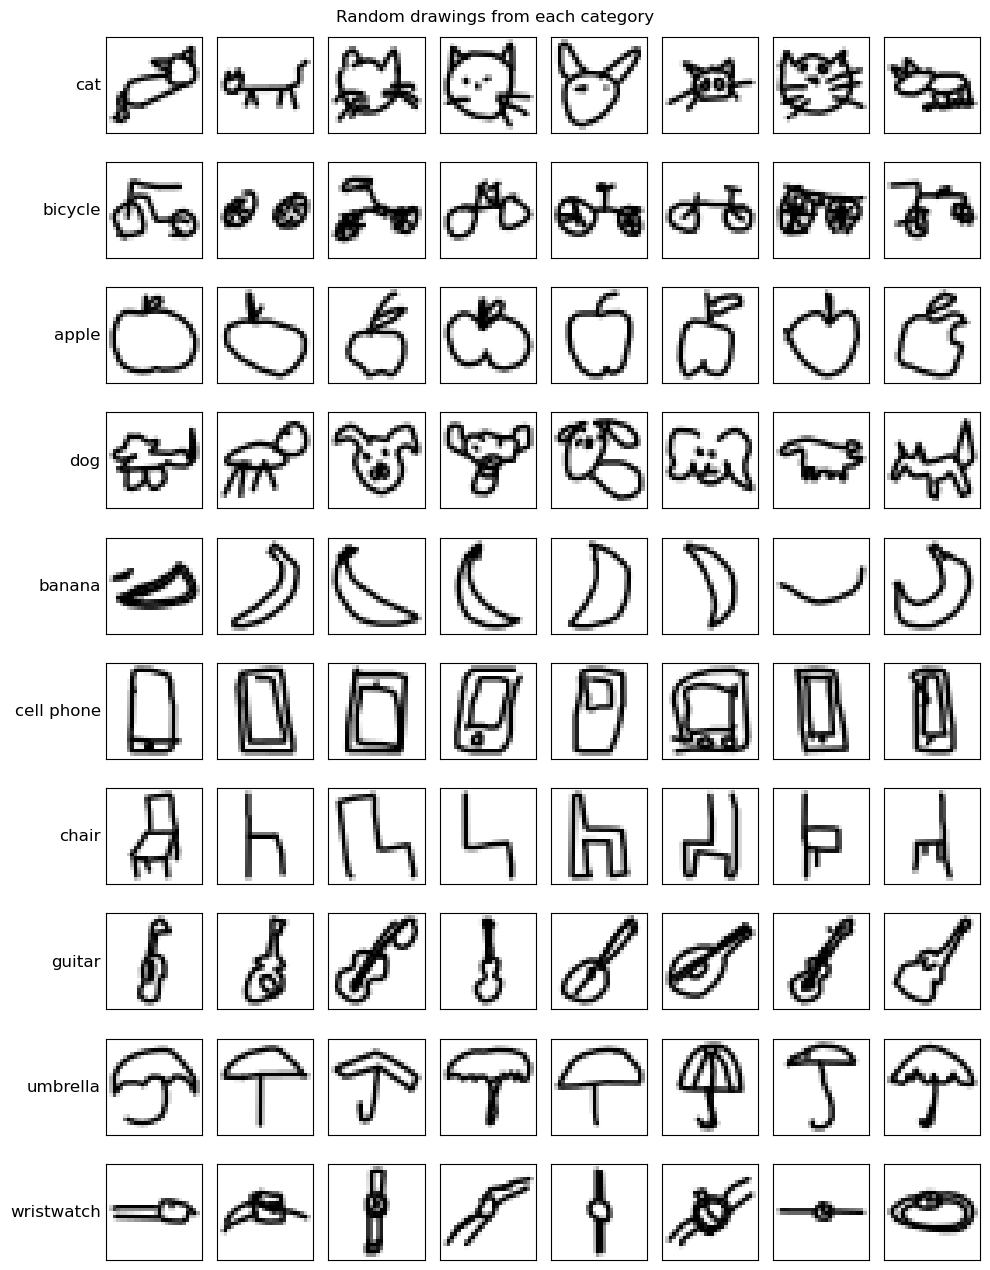

In [5]:
fig, axes = plt.subplots(len(CLASSES), 8, figsize=(10, 13))
for row, category in enumerate(CLASSES):
    picks = rng.choice(N_PER_CLASS, size=8, replace=False)   # 8 different drawings, no repeats
    for col, i in enumerate(picks):
        ax = axes[row, col]
        ax.imshow(per_class[row][i], cmap="gray_r")   # gray_r: ink is dark on white, like paper
        ax.set_xticks([]), ax.set_yticks([])           # the axis numbers mean nothing here
    axes[row, 0].set_ylabel(category, rotation=0, ha="right", va="center", fontsize=12)  # class name on the left
fig.suptitle("Random drawings from each category")
plt.tight_layout()
plt.show()

The same class can look very different. Cats get drawn as a whole body or just a face, bicycles go from two
circles to a full frame, and a wristwatch is sometimes just a line with a dot on it. Other classes are very
consistent, like banana and umbrella. That's what the models have to deal with: there's no single "correct" cat.

pixels with ink: 27.4% on average (min 1.3%, max 70.0%)


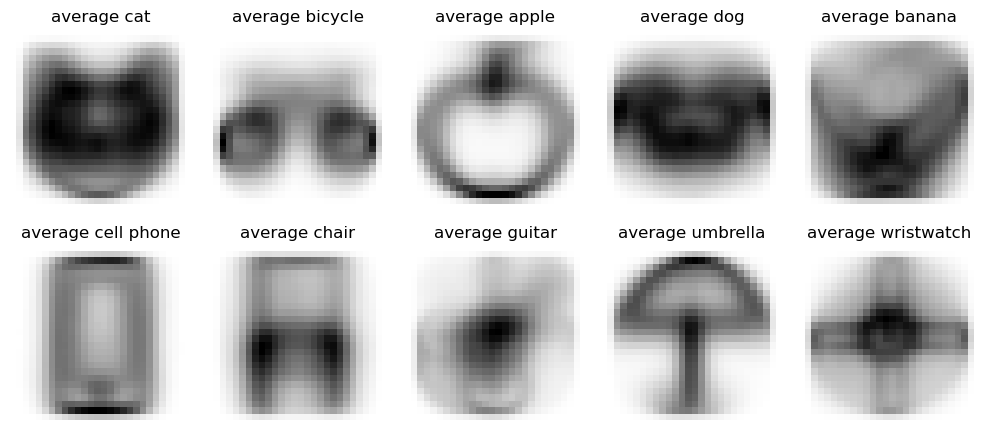

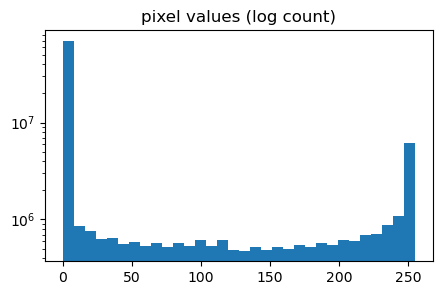

In [6]:
ink = (X > 0).mean(axis=(1, 2))   # fraction of pixels with any ink, per drawing
print(f"pixels with ink: {ink.mean():.1%} on average (min {ink.min():.1%}, max {ink.max():.1%})")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))
for ax, category, images in zip(axes.flat, CLASSES, per_class):
    ax.imshow(images.mean(axis=0), cmap="gray_r")   # all 12,000 drawings of the class, averaged
    ax.set_title(f"average {category}")
    ax.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.hist(X.ravel(), bins=32, log=True)   # log scale, or the zeros drown out everything else
plt.title("pixel values (log count)")
plt.show()

On average only 27.4% of a drawing's pixels have any ink, anywhere from 1.3% to 70.0%. The class averages are
blurry but most are still recognizable: the umbrella's dome and handle, the apple's outline and stem, the
bicycle's two wheels, the phone's rectangle. Cat and dog, though, average out to almost the same dark blob with
ears, a first hint that they'll be the hardest pair to tell apart. The histogram (log scale) shows pixels are
mostly 0 or 255, blank paper or solid ink, with a thinner spread of grays in between from the smoothed edges
of the lines.

## 3. Train, validation and test sets

A model is judged by how well it does on drawings it has never seen, so before any training we set
two groups aside:

- **train** (80%): the model learns from these.
- **validation** (10%): we compare models and settings on these.
- **test** (10%): used once, at the very end, to report the final score.

The split is stratified: each category is split 80/10/10 on its own, so all three sets keep the same
class balance.

In [7]:
def stratified_split(y, fractions=(0.8, 0.1), seed=SEED):
    """Indices for train / validation / test (the rest); every class is split in the same proportions."""
    split_rng = np.random.default_rng(seed)
    parts = ([], [], [])
    for label in np.unique(y):
        idx = split_rng.permutation(np.flatnonzero(y == label))
        n_train = int(len(idx) * fractions[0])
        n_val = int(len(idx) * fractions[1])
        parts[0].append(idx[:n_train])
        parts[1].append(idx[n_train:n_train + n_val])
        parts[2].append(idx[n_train + n_val:])
    return tuple(split_rng.permutation(np.concatenate(p)) for p in parts)


train_idx, val_idx, test_idx = stratified_split(y)
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s} {len(labels):5,d} drawings, per class {np.bincount(labels)}")
assert len(set(train_idx) | set(val_idx) | set(test_idx)) == len(y), "the three sets overlap"

train 96,000 drawings, per class [9600 9600 9600 9600 9600 9600 9600 9600 9600 9600]
val   12,000 drawings, per class [1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]
test  12,000 drawings, per class [1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]
